# Errors, subgroup stability and supported claims

Inspect false positives and false negatives, slices, threshold trade-offs, and fixed-capacity ranking. No threshold is called optimal without costs. Week-cluster bootstrap is approximate conditional stability, not population coverage: only 27 weeks, possible nonexchangeability, unknown repeated-guest dependence, and no model refitting. This notebook also regenerates the report directly from results.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd()/'src').is_dir() else Path.cwd().parent
assert (ROOT/'src/utils.py').exists(), 'Run from project root or notebooks/'
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src import analysis
pd.set_option('display.max_colwidth', 100)


## Run this stage

The shared implementation in `src/analysis.py` produces the tables and figures. Run notebooks in numerical order on a fresh project. The source is part of the submitted, editable analysis.

In [2]:
result = analysis.errors()
display(result)

,grouping,group,small_group,n,prevalence,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1,specificity,brier,log_loss,tn,fp,fn,tp
0,hotel,City Hotel,False,9418,0.296666,0.5,0.650629,0.423176,0.702060,0.499819,0.269231,0.002505,0.004965,0.997132,0.199859,0.585709,6605,19,2787,7
1,hotel,Resort Hotel,False,4670,0.191649,0.5,0.621939,0.275804,0.808137,0.501572,0.444444,0.004469,0.008850,0.998675,0.152436,0.483217,3770,5,891,4
2,market_segment,Aviation,True,63,0.222222,0.5,0.427843,0.307670,0.777778,0.500000,0.000000,0.000000,0.000000,1.000000,0.174480,0.535195,49,0,14,0
3,market_segment,Complementary,False,174,0.137931,0.5,0.529583,0.352052,0.862069,0.500000,0.000000,0.000000,0.000000,1.000000,0.119109,0.414181,150,0,24,0
4,market_segment,Corporate,False,901,0.102109,0.5,0.549276,0.131932,0.897891,0.500000,0.000000,0.000000,0.000000,1.000000,0.095382,0.343026,809,0,92,0
5,market_segment,Direct,False,1957,0.141543,0.5,0.570483,0.176808,0.858457,0.500000,0.000000,0.000000,0.000000,1.000000,0.122354,0.413831,1680,0,277,0
6,market_segment,Groups,False,711,0.416315,0.5,0.803354,0.772836,0.582278,0.498795,0.000000,0.000000,0.000000,0.997590,0.221052,0.629047,414,1,296,0
7,market_segment,Offline TA/TO,False,1807,0.190924,0.5,0.603865,0.237778,0.801882,0.498876,0.157895,0.008696,0.016484,0.989056,0.156014,0.487297,1446,16,342,3
8,market_segment,Online TA,False,8475,0.311622,0.5,0.618721,0.407437,0.688496,0.500915,0.533333,0.003029,0.006024,0.998800,0.212149,0.615967,5827,7,2633,8
9,lead_band,0–7,False,3927,0.098039,0.5,0.573435,0.133857,0.901961,0.500000,0.000000,0.000000,0.000000,1.000000,0.092545,0.334614,3542,0,385,0


In [3]:
display(pd.read_csv(ROOT/'tables/error_summary.csv'))

,error_type,n,mean_score,median_lead,mean_adults
0,FN,3678,0.253321,37.0,1.849375
1,FP,24,0.525313,157.0,2.250000
2,TN,10375,0.204145,18.0,1.800771
3,TP,11,0.545614,125.0,2.181818


In [4]:
display(pd.read_csv(ROOT/'tables/week_cluster_bootstrap.csv'))

,metric,lower_2_5,upper_97_5,replicates,week_clusters,interpretation
0,roc_auc,0.637608,0.682247,400,27,"Approximate conditional stability interval; fixed fitted model, exchangeable weeks assumed."
1,auc_gain,0.137608,0.182247,400,27,"Approximate conditional stability interval; fixed fitted model, exchangeable weeks assumed."
2,brier_gain,0.007240,0.015773,400,27,"Approximate conditional stability interval; fixed fitted model, exchangeable weeks assumed."


In [5]:
display(pd.read_csv(ROOT/'tables/threshold_diagnostics.csv')[['threshold','precision','recall','fp','fn']])

,threshold,precision,recall,fp,fn
0,0.2,0.337254,0.738411,5353,965
1,0.3,0.430782,0.286799,1398,2631
2,0.4,0.545961,0.053131,163,3493
3,0.5,0.314286,0.002982,24,3678
4,0.6,0.500000,0.000271,1,3688
5,0.7,0.000000,0.000000,0,3689
6,0.8,0.000000,0.000000,0,3689


In [6]:
display(pd.read_csv(ROOT/'tables/ranking_capacity.csv'))

,capacity_fraction,k,precision_at_k,recall_at_k,tie_rule
0,0.05,705,0.507801,0.097045,ascending original row_id
1,0.10,1409,0.481902,0.184061,ascending original row_id
2,0.20,2818,0.417317,0.318786,ascending original row_id


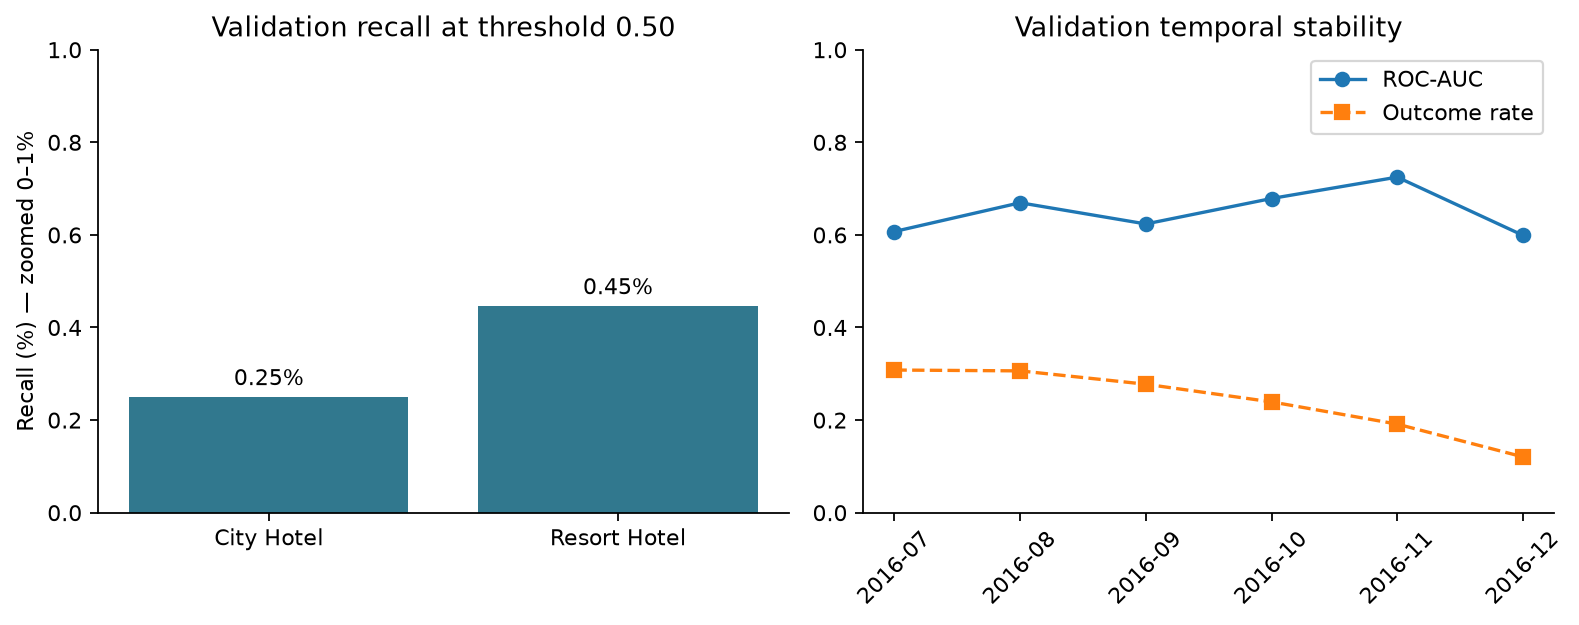

In [7]:
display(Image(filename=str(ROOT/'figures/06_subgroup_temporal.png')))

In [8]:
from src.reporting import write_report
write_report()

{'train_n': 39865,
 'validation_n': 14088,
 'train_prevalence': 0.30748777122789417,
 'validation_prevalence': 0.2618540601930721,
 'auc': 0.6583626529971357,
 'recall': 0.0029818378964489,
 'accuracy': 0.7372231686541738,
 'holdout_n': 26565,
 'recommendation': 'HOLD',
 'course_assignment_screenshot_verified': False}

In [9]:
display(pd.read_csv(ROOT/'tables/claim_evidence.csv'))

,claim,evidence,status_or_limit,artifact
0,Logistic scores show modest discrimination on the eligible retrospective validation cohort.,"AUC 0.6584; Dummy 0.5000; approximate week-bootstrap interval [0.6376, 0.6822].",Supported for this cohort only.,tables/validation_metrics.csv; tables/week_cluster_bootstrap.csv
1,The default 0.5 threshold is unsuitable for a high-recall non-completion alert.,"TP=11, FN=3678, recall=0.30%; accuracy=73.72%.",Supported descriptive failure; operational cost still unknown.,figures/04_confusion_matrix.png
2,Ranking may be more useful than the default hard decisions.,"Top 10% precision=48.19%, recall=18.41%, overall prevalence=26.19%.",Exploratory retrospective result; capacity and utility unvalidated.,tables/ranking_capacity.csv
3,This is a valid deployed reservation-time model.,No original feature snapshots or confirmed creation timestamps.,Not supported; HOLD deployment.,tables/prediction_time_leakage_audit.csv
4,A feature causes customers to cancel.,"Observational records, no intervention or identification design.",Not supported.,report/MIDTERM_REPORT_DRAFT.md
5,"The same performance applies to all hotels, countries, or future years.",Two specific Portuguese hotels; arrival-window selection; no external validation.,Not supported.,docs/SOURCES.md
6,Deduplication resolves repeated-guest dependence.,Exact-row sensitivity is available; guest/group IDs are absent.,Not supported; dependence persists.,tables/development_audit.csv
7,Final-test performance is known.,Final holdout not scored.,Not evaluated.,data/processed/HOLDOUT_POLICY.md


## Interpretation boundary

These outputs concern a selected retrospective cohort. Review the report and leakage audit before interpreting model quality. The final holdout remains unscored.